# Мультимодальное распознавание эмоций (MER)

Пайплайн: **Видео → детекция лиц → MobileNetV2 (backbone) → темпоральная агрегация → классификация эмоции**

Три подхода на видео-части (датасет **RAVDESS**, full-AV видео):
1. **Наш подход — MobileNetV2 + Attention Pooling** — 8 кадров → MobileNetV2 → обучаемый attention pooling → классификатор
2. **Базовая линия — MobileNetV2 + BiLSTM** — 8 кадров → MobileNetV2 → двунаправленный LSTM → классификатор
3. **Сильная модель — MobileNetV2 + Transformer** — 8 кадров → MobileNetV2 → Transformer Encoder → классификатор

Метрики: **Качество** (Accuracy, F1 macro, Precision, Recall) · **Скорость** инференса · **Размер** модели

In [51]:
import os, io, time, gc, warnings
warnings.filterwarnings("ignore")

import cv2
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import torchvision.models as models
import torchvision.transforms as T

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report,
)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

SR = 16_000
N_MELS, MAX_LEN, HOP = 64, 128, 512
IMG_SIZE = 224
N_FRAMES = 8
results = []

EMOTION_MAP = {
    1: "neutral", 2: "calm", 3: "happy", 4: "sad",
    5: "angry", 6: "fearful", 7: "disgust", 8: "surprised",
}
N_CLASSES = len(EMOTION_MAP)


def pytorch_size_mb(model):
    b = sum(p.numel() * p.element_size() for p in model.parameters())
    b += sum(x.numel() * x.element_size() for x in model.buffers())
    return b / 1024 ** 2

Device: mps


## 1. Загрузка видео-данных RAVDESS

In [52]:
RAVDESS_PATH = "../datasets/orvile/ravdess-dataset/versions/1/"

video_paths, emo_labels, actor_ids = [], [], []

for d in sorted(os.listdir(RAVDESS_PATH)):
    if not d.startswith("Video_Speech_Actor_"):
        continue
    actor_dir = os.path.join(RAVDESS_PATH, d)
    for actor_sub in sorted(os.listdir(actor_dir)):
        if not actor_sub.startswith("Actor_"):
            continue
        actor_path = os.path.join(actor_dir, actor_sub)
        for f in sorted(os.listdir(actor_path)):
            if not f.endswith(".mp4"):
                continue
            parts = f.replace(".mp4", "").split("-")
            modality = int(parts[0])
            if modality != 1:
                continue
            emotion = int(parts[2])
            actor = int(parts[6])
            video_paths.append(os.path.join(actor_path, f))
            emo_labels.append(emotion - 1)
            actor_ids.append(actor)

emo_labels = np.array(emo_labels)
actor_ids = np.array(actor_ids)

unique_actors = sorted(set(actor_ids))
n_test_actors = max(1, len(unique_actors) // 5)
test_actors = set(unique_actors[-n_test_actors:])

train_idx = [i for i, a in enumerate(actor_ids) if a not in test_actors]
test_idx  = [i for i, a in enumerate(actor_ids) if a in test_actors]

train_videos = [video_paths[i] for i in train_idx]
test_videos  = [video_paths[i] for i in test_idx]
y_train = emo_labels[train_idx]
y_test  = emo_labels[test_idx]

print(f"Всего видео (full-AV speech): {len(video_paths)}")
for emo_id, name in EMOTION_MAP.items():
    print(f"  {name}: {(emo_labels == emo_id - 1).sum()}")
print(f"\nSpeaker-independent split (20 % актёров → test):")
print(f"  Train: {len(train_videos)} видео ({len(unique_actors) - n_test_actors} актёров)")
print(f"  Test:  {len(test_videos)} видео ({n_test_actors} актёров)")

Всего видео (full-AV speech): 1440
  neutral: 96
  calm: 192
  happy: 192
  sad: 192
  angry: 192
  fearful: 192
  disgust: 192
  surprised: 192

Speaker-independent split (20 % актёров → test):
  Train: 1200 видео (20 актёров)
  Test:  240 видео (4 актёров)


## 2. Детекция лиц и извлечение визуальных признаков (MobileNetV2)

In [39]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

imagenet_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def extract_frames(video_path, n_frames=8):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return []
    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames


def detect_and_crop_face(frame, target_size=IMG_SIZE):
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(48, 48))
    if len(faces) > 0:
        x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
        pad = int(0.2 * max(w, h))
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(frame.shape[1], x + w + pad)
        y2 = min(frame.shape[0], y + h + pad)
        face = frame[y1:y2, x1:x2]
    else:
        h, w = frame.shape[:2]
        s = min(h, w)
        y1, x1 = (h - s) // 2, (w - s) // 2
        face = frame[y1:y1 + s, x1:x1 + s]
    return cv2.resize(face, (target_size, target_size))


print("Утилиты загружены ✓")

Утилиты загружены ✓


In [40]:
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
mobilenet.classifier = nn.Identity()
mobilenet = mobilenet.to(device).eval()
FEAT_DIM = 1280

mobilenet_mb = pytorch_size_mb(mobilenet)
print(f"MobileNetV2 feature extractor: {mobilenet_mb:.1f} MB, output dim={FEAT_DIM}")


def extract_vis_features(video_list, n_frames=N_FRAMES):
    all_feats = []
    for vp in tqdm(video_list):
        frames = extract_frames(vp, n_frames)
        if not frames:
            all_feats.append(torch.zeros(n_frames, FEAT_DIM))
            continue
        while len(frames) < n_frames:
            frames.append(frames[-1])
        faces = torch.stack(
            [imagenet_transform(detect_and_crop_face(f)) for f in frames[:n_frames]]
        )
        with torch.no_grad():
            feats = mobilenet(faces.to(device)).cpu()
        all_feats.append(feats)
    return torch.stack(all_feats)


print("Извлечение визуальных признаков (MobileNetV2)...")
train_vis = extract_vis_features(train_videos)
test_vis  = extract_vis_features(test_videos)
print(f"Train visual: {train_vis.shape}  |  Test visual: {test_vis.shape}")

MobileNetV2 feature extractor: 8.6 MB, output dim=1280
Извлечение визуальных признаков (MobileNetV2)...


100%|██████████| 240/240 [00:53<00:00,  4.46it/s]

Train visual: torch.Size([1200, 8, 1280])  |  Test visual: torch.Size([240, 8, 1280])


## 3. Наш подход: MobileNetV2 + Attention Pooling

8 кадров → детекция лиц → MobileNetV2 признаки → обучаемый **Attention Pooling** → FC-классификатор

Attention-веса вычисляются из самих признаков (score = Tanh(W·f)), что позволяет модели
автоматически фокусироваться на наиболее информативных кадрах.

In [41]:
class AttentionPoolingClassifier(nn.Module):
    def __init__(self, feat_dim=1280, n_classes=8, hidden=128):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(feat_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        # x: (batch, n_frames, feat_dim)
        attn_weights = self.attention(x)           # (batch, n_frames, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)
        pooled = (attn_weights * x).sum(dim=1)     # (batch, feat_dim)
        return self.classifier(pooled)


model_1 = AttentionPoolingClassifier(FEAT_DIM, N_CLASSES).to(device)
opt1 = optim.Adam(model_1.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.CrossEntropyLoss()

ds1 = TensorDataset(train_vis, torch.tensor(y_train, dtype=torch.long))
loader1 = DataLoader(ds1, batch_size=32, shuffle=True)

t0 = time.time()
for ep in range(50):
    model_1.train()
    for xb, yb in loader1:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit(model_1(xb), yb)
        opt1.zero_grad(); loss.backward(); opt1.step()
    if (ep + 1) % 10 == 0:
        model_1.eval()
        with torch.no_grad():
            acc = (model_1(train_vis.to(device)).argmax(1).cpu().numpy() == y_train).mean()
        print(f"Epoch {ep+1}/50 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_1 = time.time() - t0

# End-to-end инференс
model_1.eval()
t0 = time.time()
preds_1 = []
for vp in test_videos:
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        frames = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    while len(frames) < N_FRAMES:
        frames.append(frames[-1])
    faces = torch.stack(
        [imagenet_transform(detect_and_crop_face(f)) for f in frames[:N_FRAMES]]
    )
    with torch.no_grad():
        feats = mobilenet(faces.to(device)).unsqueeze(0)  # (1, N_FRAMES, FEAT_DIM)
        preds_1.append(model_1(feats).argmax(1).item())
inf_time_1 = (time.time() - t0) / len(test_videos)
preds_1 = np.array(preds_1)

cls_1_mb = pytorch_size_mb(model_1)
pipe_1_mb = mobilenet_mb + cls_1_mb

results.append({
    "Модель": "Attention Pooling",
    "Accuracy": accuracy_score(y_test, preds_1),
    "F1 (macro)": f1_score(y_test, preds_1, average="macro"),
    "Precision": precision_score(y_test, preds_1, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_1, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_1 * 1000,
    "Обучение (сек)": train_time_1,
    "Классификатор (MB)": cls_1_mb,
    "Пайплайн (MB)": pipe_1_mb,
})
print(f"\nAttention Pooling → Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_1*1000:.1f} мс/файл  Pipeline={pipe_1_mb:.1f} MB")

Epoch 10/50 | Loss 1.2885 | Train Acc 0.6567
Epoch 20/50 | Loss 0.9125 | Train Acc 0.8008
Epoch 30/50 | Loss 0.8843 | Train Acc 0.8950
Epoch 40/50 | Loss 0.2725 | Train Acc 0.9300
Epoch 50/50 | Loss 0.4135 | Train Acc 0.9508

Attention Pooling → Acc=0.3875 F1=0.3792 Inf=222.5 мс/файл  Pipeline=9.6 MB


## 4. Базовая линия: MobileNetV2 + BiLSTM

8 кадров → детекция лиц → MobileNetV2 признаки → **Двунаправленный LSTM** → FC-классификатор

Конкатенация финальных скрытых состояний прямого и обратного проходов
даёт признаковый вектор размера `2 × hidden`, который подаётся в классификатор.

In [42]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, feat_dim=1280, hidden=256, n_classes=8):
        super().__init__()
        self.bilstm = nn.LSTM(
            feat_dim, hidden, batch_first=True, bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        # x: (batch, n_frames, feat_dim)
        _, (h, _) = self.bilstm(x)
        h = torch.cat([h[0], h[1]], dim=1)  # (batch, hidden*2)
        return self.classifier(h)


model_2 = BiLSTMClassifier(FEAT_DIM, hidden=256, n_classes=N_CLASSES).to(device)
opt2 = optim.Adam(model_2.parameters(), lr=1e-3, weight_decay=1e-4)

ds2 = TensorDataset(train_vis, torch.tensor(y_train, dtype=torch.long))
loader2 = DataLoader(ds2, batch_size=32, shuffle=True)

t0 = time.time()
for ep in range(50):
    model_2.train()
    for xb, yb in loader2:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit(model_2(xb), yb)
        opt2.zero_grad(); loss.backward(); opt2.step()
    if (ep + 1) % 10 == 0:
        model_2.eval()
        with torch.no_grad():
            acc = (model_2(train_vis.to(device)).argmax(1).cpu().numpy() == y_train).mean()
        print(f"Epoch {ep+1}/50 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_2 = time.time() - t0

# End-to-end инференс
model_2.eval()
t0 = time.time()
preds_2 = []
for vp in test_videos:
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        frames = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    while len(frames) < N_FRAMES:
        frames.append(frames[-1])
    faces = torch.stack(
        [imagenet_transform(detect_and_crop_face(f)) for f in frames[:N_FRAMES]]
    )
    with torch.no_grad():
        feats = mobilenet(faces.to(device)).unsqueeze(0)  # (1, N_FRAMES, FEAT_DIM)
        preds_2.append(model_2(feats).argmax(1).item())
inf_time_2 = (time.time() - t0) / len(test_videos)
preds_2 = np.array(preds_2)

cls_2_mb = pytorch_size_mb(model_2)
pipe_2_mb = mobilenet_mb + cls_2_mb

results.append({
    "Модель": "BiLSTM",
    "Accuracy": accuracy_score(y_test, preds_2),
    "F1 (macro)": f1_score(y_test, preds_2, average="macro"),
    "Precision": precision_score(y_test, preds_2, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_2, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_2 * 1000,
    "Обучение (сек)": train_time_2,
    "Классификатор (MB)": cls_2_mb,
    "Пайплайн (MB)": pipe_2_mb,
})
print(f"\nBiLSTM → Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_2*1000:.1f} мс/файл  Pipeline={pipe_2_mb:.1f} MB")

Epoch 10/50 | Loss 1.3676 | Train Acc 0.6358
Epoch 20/50 | Loss 1.3126 | Train Acc 0.7308
Epoch 30/50 | Loss 0.4198 | Train Acc 0.8717
Epoch 40/50 | Loss 0.5577 | Train Acc 0.9458
Epoch 50/50 | Loss 0.1132 | Train Acc 0.9867

BiLSTM → Acc=0.4708 F1=0.4558 Inf=211.0 мс/файл  Pipeline=20.9 MB


## 5. Сильная модель: MobileNetV2 + Transformer

8 кадров → детекция лиц → MobileNetV2 признаки → **Transformer Encoder** → Global Average Pooling → FC-классификатор

Self-attention механизм позволяет каждому кадру «обращать внимание» на все остальные кадры,
что обеспечивает глобальный контекст по всей последовательности.

In [43]:
class TransformerClassifier(nn.Module):
    def __init__(self, feat_dim=1280, n_heads=4, n_layers=2, n_classes=8, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(feat_dim, 256)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256, nhead=n_heads, dim_feedforward=512,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        # x: (batch, n_frames, feat_dim)
        x = self.proj(x)                       # (batch, n_frames, 256)
        x = self.transformer(x)                # (batch, n_frames, 256)
        x = x.mean(dim=1)                      # global average pooling
        return self.classifier(x)


model_3 = TransformerClassifier(FEAT_DIM, n_heads=4, n_layers=2, n_classes=N_CLASSES).to(device)
opt3 = optim.Adam(model_3.parameters(), lr=1e-3, weight_decay=1e-4)

ds3 = TensorDataset(train_vis, torch.tensor(y_train, dtype=torch.long))
loader3 = DataLoader(ds3, batch_size=32, shuffle=True)

t0 = time.time()
for ep in range(50):
    model_3.train()
    for xb, yb in loader3:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit(model_3(xb), yb)
        opt3.zero_grad(); loss.backward(); opt3.step()
    if (ep + 1) % 10 == 0:
        model_3.eval()
        with torch.no_grad():
            acc = (model_3(train_vis.to(device)).argmax(1).cpu().numpy() == y_train).mean()
        print(f"Epoch {ep+1}/50 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_3 = time.time() - t0

# End-to-end инференс
model_3.eval()
t0 = time.time()
preds_3 = []
for vp in test_videos:
    frames = extract_frames(vp, N_FRAMES)
    if not frames:
        frames = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)] * N_FRAMES
    while len(frames) < N_FRAMES:
        frames.append(frames[-1])
    faces = torch.stack(
        [imagenet_transform(detect_and_crop_face(f)) for f in frames[:N_FRAMES]]
    )
    with torch.no_grad():
        feats = mobilenet(faces.to(device)).unsqueeze(0)  # (1, N_FRAMES, FEAT_DIM)
        preds_3.append(model_3(feats).argmax(1).item())
inf_time_3 = (time.time() - t0) / len(test_videos)
preds_3 = np.array(preds_3)

cls_3_mb = pytorch_size_mb(model_3)
pipe_3_mb = mobilenet_mb + cls_3_mb

results.append({
    "Модель": "Transformer",
    "Accuracy": accuracy_score(y_test, preds_3),
    "F1 (macro)": f1_score(y_test, preds_3, average="macro"),
    "Precision": precision_score(y_test, preds_3, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_3, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_3 * 1000,
    "Обучение (сек)": train_time_3,
    "Классификатор (MB)": cls_3_mb,
    "Пайплайн (MB)": pipe_3_mb,
})
print(f"\nTransformer → Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_3*1000:.1f} мс/файл  Pipeline={pipe_3_mb:.1f} MB")

Epoch 10/50 | Loss 2.0405 | Train Acc 0.1333
Epoch 20/50 | Loss 2.0901 | Train Acc 0.1333
Epoch 30/50 | Loss 2.0621 | Train Acc 0.1333
Epoch 40/50 | Loss 2.0683 | Train Acc 0.1333
Epoch 50/50 | Loss 2.0701 | Train Acc 0.2142

Transformer → Acc=0.1750 F1=0.0812 Inf=213.3 мс/файл  Pipeline=14.0 MB


## 6. Сводная таблица и визуализация

In [45]:
df = pd.DataFrame(results)

fmt = {
    "Accuracy": "{:.4f}", "F1 (macro)": "{:.4f}",
    "Precision": "{:.4f}", "Recall": "{:.4f}",
    "Инференс (мс/файл)": "{:.1f}",
    "Обучение (сек)": "{:.1f}",
    "Классификатор (MB)": "{:.3f}",
    "Пайплайн (MB)": "{:.2f}",
}
print(df.to_string(index=False, formatters={k: v.format for k, v in fmt.items()}))

emo_names = [EMOTION_MAP[i + 1] for i in range(N_CLASSES)]

for name, preds in [
    ("Attention Pooling", preds_1),
    ("BiLSTM", preds_2),
    ("Transformer", preds_3),
]:
    print(f"\n{'=' * 60}")
    print(name)
    print(classification_report(y_test, preds, target_names=emo_names, zero_division=0))

           Модель Accuracy F1 (macro) Precision Recall Инференс (мс/файл) Обучение (сек) Классификатор (MB) Пайплайн (MB)
Attention Pooling   0.3875     0.3792    0.4427 0.3906              222.5            8.3              0.942          9.56
           BiLSTM   0.4708     0.4558    0.5621 0.5000              211.0           14.5             12.270         20.88
      Transformer   0.1750     0.0812    0.0730 0.1641              213.3           22.8              5.402         14.02

Attention Pooling
              precision    recall  f1-score   support

     neutral       0.44      0.44      0.44        16
        calm       0.52      0.38      0.44        32
       happy       0.55      0.53      0.54        32
         sad       0.32      0.34      0.33        32
       angry       0.30      0.72      0.43        32
     fearful       0.33      0.16      0.21        32
     disgust       0.75      0.19      0.30        32
   surprised       0.32      0.38      0.35        32

    a

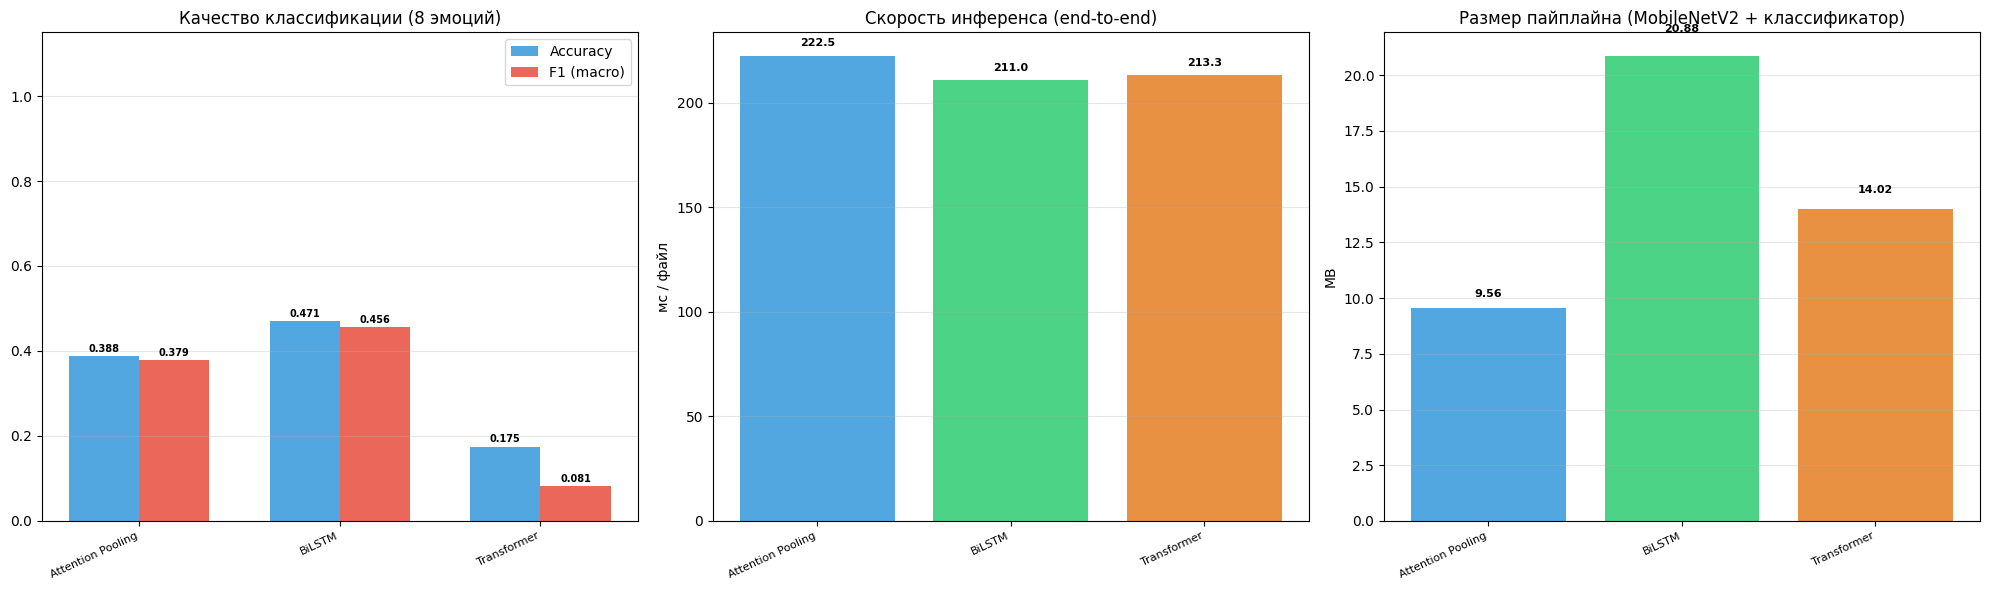

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
model_names = df["Модель"].tolist()
x = np.arange(len(model_names))
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c", "#1abc9c"]

# ── Качество ──
w = 0.35
b1 = axes[0].bar(x - w / 2, df["Accuracy"], w,
                  label="Accuracy", color="#3498db", alpha=0.85)
b2 = axes[0].bar(x + w / 2, df["F1 (macro)"], w,
                  label="F1 (macro)", color="#e74c3c", alpha=0.85)
axes[0].set_ylim(0, 1.15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=8, rotation=25, ha="right")
axes[0].set_title("Качество классификации (8 эмоций)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for b in list(b1) + list(b2):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                 f"{b.get_height():.3f}", ha="center", fontsize=7, fontweight="bold")

# ── Скорость инференса ──
b3 = axes[1].bar(x, df["Инференс (мс/файл)"], color=colors, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, fontsize=8, rotation=25, ha="right")
axes[1].set_ylabel("мс / файл")
axes[1].set_title("Скорость инференса (end-to-end)")
axes[1].grid(axis="y", alpha=0.3)
for b in b3:
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() * 1.02,
                 f"{b.get_height():.1f}", ha="center", fontsize=8, fontweight="bold")

# ── Размер пайплайна ──
b4 = axes[2].bar(x, df["Пайплайн (MB)"], color=colors, alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names, fontsize=8, rotation=25, ha="right")
axes[2].set_ylabel("MB")
axes[2].set_title("Размер пайплайна (MobileNetV2 + классификатор)")
axes[2].grid(axis="y", alpha=0.3)
for b in b4:
    axes[2].text(b.get_x() + b.get_width() / 2, b.get_height() * 1.05,
                 f"{b.get_height():.2f}", ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()